# Vanguard Digital Experiment 

## Business Context

Vanguard ran an A/B test from **3/15/2017 to 6/20/2017** to evaluate whether a redesigned digital interface could make the online process smoother and increase process completion. Clients move through the funnel:

`start -> step_1 -> step_2 -> step_3 -> confirm`

- **Control:** traditional interface
- **Test:** redesigned interface

## Objective of this notebook

This notebook combines:

### Dataset Exploration, Cleaning & Client Behavior

- Rebuild the cleaned experiment-ready dataset
- Understand who uses the online process
- Analyze whether clients are younger/older and new/long-standing
- Explore client behavior through logons, calls and digital engagement
- Check whether Test and Control groups are reasonably balanced before evaluating the experiment

### Performance Metrics / KPIs

- Completion rate
- Time spent on each step
- Error rate
- Funnel drop-off, bounce rate, step repeats and time-to-complete
- Descriptive redesign verdict before formal hypothesis testing

## Unit of analysis

For user journey and KPI analysis, the primary unit is the **visit (`visit_id`)**, which represents one session or one attempt at the funnel.


In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")

# Consistent group colors
GROUP_COLORS = {"Control": "#4C78A8", "Test": "#F58518"}

## 1. Load Cleaned Analytical Dataset

This notebook uses the cleaned datasets generated during Phase 1.

All data cleaning, validation, duplicate handling, missing value treatment, feature engineering and dataset merging were completed in the Data Cleaning notebook.

This approach keeps the workflow modular, reproducible and aligned with professional analytics practices.

**Dataset used:**
- `vanguard_cleaned_merged.csv` → master analytical dataset containing web events, experiment assignment, demographics and engineered features.


In [2]:
# Load cleaned analytical dataset

df = pd.read_csv("vanguard_cleaned_merged.csv")

df["date_time"] = pd.to_datetime(df["date_time"])

print("Dataset shape:", df.shape)
display(df.head())

print("\nVariation distribution:")
display(df["Variation"].value_counts(dropna=False))

print("\nProcess step distribution:")
display(df["process_step"].value_counts())


Dataset shape: (317235, 19)


,client_id,visitor_id,visit_id,process_step,date_time,Variation,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,age_group,tenure_group,balance_segment,date,year_month
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000,70+,New,Very High,2017-04-17,2017-04
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000,70+,New,Very High,2017-04-17,2017-04
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000,70+,New,Very High,2017-04-17,2017-04
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000,70+,New,Very High,2017-04-17,2017-04
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04,Test,5.0000,64.0000,79.0000,Unknown,2.0000,"189,023.8600",1.0000,4.0000,70+,New,Very High,2017-04-17,2017-04



Variation distribution:


Variation
Test       176699
Control    140536
Name: count, dtype: int64


Process step distribution:


process_step
start      101153
step_1      68210
step_2      56672
step_3      48264
confirm     42936
Name: count, dtype: int64

### 1.1 Data Readiness Check

Before calculating KPIs, we verify that the cleaned dataset contains all required fields for the analysis.


In [3]:
required_columns = [
    "client_id", "visit_id", "process_step", "date_time",
    "Variation", "clnt_age", "clnt_tenure_yr", "bal"
]

missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")


All required columns are present.


### 1.1 Encode the funnel order

We map each step to an ordinal index so we can detect forward vs backward
movement, and sort every visit chronologically.

In [4]:
STEP_ORDER = {"start": 0, "step_1": 1, "step_2": 2, "step_3": 3, "confirm": 4}
STEP_NAMES = ["start", "step_1", "step_2", "step_3", "confirm"]

df["step_index"] = df["process_step"].map(STEP_ORDER)

# Sort events chronologically within each visit (the journey timeline)
df = df.sort_values(["client_id", "visit_id", "date_time"]).reset_index(drop=True)

print("Unique visits:", df["visit_id"].nunique())
print("Unique clients:", df["client_id"].nunique())
df[["client_id", "visit_id", "process_step", "step_index", "date_time", "Variation"]].head(10)

Unique visits: 69205
Unique clients: 50500


,client_id,visit_id,process_step,step_index,date_time,Variation
0,555,637149525_38041617439_716659,start,0,2017-04-15 12:57:56,Test
1,555,637149525_38041617439_716659,step_1,1,2017-04-15 12:58:03,Test
2,555,637149525_38041617439_716659,step_2,2,2017-04-15 12:58:35,Test
3,555,637149525_38041617439_716659,step_3,3,2017-04-15 13:00:14,Test
4,555,637149525_38041617439_716659,confirm,4,2017-04-15 13:00:34,Test
5,647,40369564_40101682850_311847,start,0,2017-04-12 15:41:28,Test
6,647,40369564_40101682850_311847,step_1,1,2017-04-12 15:41:35,Test
7,647,40369564_40101682850_311847,step_2,2,2017-04-12 15:41:53,Test
8,647,40369564_40101682850_311847,step_3,3,2017-04-12 15:45:02,Test
9,647,40369564_40101682850_311847,confirm,4,2017-04-12 15:47:45,Test


### 1.2 Build a per-visit summary table

One row per `visit_id`, capturing the facts every KPI needs: the group, whether
`confirm` was reached, the furthest step, event count, and start/end timestamps.

In [5]:
visit = df.groupby("visit_id").agg(
    Variation       =("Variation", "first"),
    client_id       =("client_id", "first"),
    reached_confirm =("process_step", lambda s: "confirm" in set(s)),
    max_step        =("step_index", "max"),
    n_events        =("process_step", "size"),
    start_time      =("date_time", "min"),
    end_time        =("date_time", "max"),
)
print("Visits summarized:", len(visit))
visit.head()

Visits summarized: 69205


,Variation,client_id,reached_confirm,max_step,n_events,start_time,end_time
visit_id,,,,,,,
100012776_37918976071_457913,Test,3561384,True,4,2,2017-04-26 13:22:17,2017-04-26 13:23:09
100019538_17884295066_43909,Test,7338123,True,4,11,2017-04-09 16:20:56,2017-04-09 16:24:58
100022086_87870757897_149620,Test,2478628,True,4,5,2017-05-23 20:44:01,2017-05-23 20:47:01
100030127_47967100085_936361,Control,105007,False,0,1,2017-03-22 11:07:49,2017-03-22 11:07:49
100037962_47432393712_705583,Control,5623007,False,1,4,2017-04-14 16:41:51,2017-04-14 16:44:03



## 2. Client Demographics & Behavior Analysis

Before evaluating the A/B test performance, we first need to understand **who** is using Vanguard's online process and how these clients behave digitally.

This section answers the following questions from the project brief:

1. Who are the primary clients using this online process?
2. Are the primary clients younger or older?
3. Are they new or long-standing?
4. What additional behavior patterns are relevant for Customer Experience?



### 2.1 Create client-level dataset

The event-level dataframe contains multiple rows per client because each user can have several web events and visits. For demographic analysis, we create a **client-level table** with one row per client.


In [30]:
# One row per client for demographic and client-level behavior analysis
client = (
    df.sort_values("date_time")
      .groupby("client_id")
      .agg(
          Variation=("Variation", "first"),
          clnt_age=("clnt_age", "first"),
          gendr=("gendr", "first"),
          clnt_tenure_yr=("clnt_tenure_yr", "first"),
          clnt_tenure_mnth=("clnt_tenure_mnth", "first"),
          num_accts=("num_accts", "first"),
          bal=("bal", "first"),
          calls_6_mnth=("calls_6_mnth", "first"),
          logons_6_mnth=("logons_6_mnth", "first"),
          n_visits=("visit_id", "nunique"),
          n_events=("process_step", "size"),
          first_activity=("date_time", "min"),
          last_activity=("date_time", "max"),
      )
      .reset_index()
)

print("Client-level dataset shape:", client.shape)
client.head()

Client-level dataset shape: (50500, 14)


,client_id,Variation,clnt_age,gendr,clnt_tenure_yr,clnt_tenure_mnth,num_accts,bal,calls_6_mnth,logons_6_mnth,n_visits,n_events,first_activity,last_activity
0,555,Test,29.5000,Unknown,3.0000,46.0000,2.0000,"25,454.6600",2.0000,6.0000,1,5,2017-04-15 12:57:56,2017-04-15 13:00:34
1,647,Test,57.5000,M,12.0000,151.0000,2.0000,"30,525.8000",0.0000,4.0000,1,5,2017-04-12 15:41:28,2017-04-12 15:47:45
2,934,Test,51.0000,F,9.0000,109.0000,2.0000,"32,522.8800",0.0000,3.0000,1,4,2017-04-18 02:36:30,2017-04-18 02:38:52
3,1028,Control,36.0000,M,12.0000,145.0000,3.0000,"103,520.2200",1.0000,4.0000,1,9,2017-04-08 18:51:28,2017-04-08 19:00:26
4,1104,Control,48.0000,Unknown,5.0000,66.0000,3.0000,"154,643.9400",6.0000,9.0000,2,2,2017-06-12 07:49:18,2017-06-20 22:31:33



### 2.2 Feature engineering for demographic segmentation

To make the analysis easier to interpret and more useful for Tableau, we create age, tenure, balance and engagement segments.


In [7]:
# Age groups
client["age_group"] = pd.cut(
    client["clnt_age"],
    bins=[0, 35, 50, 65, 120],
    labels=["18-35", "36-50", "51-65", "65+"]
)

# Tenure groups
client["tenure_group"] = pd.cut(
    client["clnt_tenure_yr"],
    bins=[0, 5, 10, 20, 100],
    labels=["New (0-5 yrs)", "Established (6-10 yrs)", "Loyal (11-20 yrs)", "Veteran (20+ yrs)"],
    include_lowest=True
)

# Balance quartiles. qcut can fail if there are duplicated bin edges, so duplicates='drop' keeps it robust.
client["balance_segment"] = pd.qcut(
    client["bal"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"],
    duplicates="drop"
)

# Digital engagement: based on logons in the last 6 months
client["digital_engagement"] = pd.cut(
    client["logons_6_mnth"],
    bins=[-1, 3, 6, 9, np.inf],
    labels=["Low", "Medium", "High", "Very High"]
)

client[["client_id", "Variation", "clnt_age", "age_group", "clnt_tenure_yr", "tenure_group", "bal", "balance_segment", "logons_6_mnth", "digital_engagement"]].head()


,client_id,Variation,clnt_age,age_group,clnt_tenure_yr,tenure_group,bal,balance_segment,logons_6_mnth,digital_engagement
0,555,Test,29.5000,18-35,3.0000,New (0-5 yrs),"25,454.6600",Low,6.0000,Medium
1,647,Test,57.5000,51-65,12.0000,Loyal (11-20 yrs),"30,525.8000",Low,4.0000,Medium
2,934,Test,51.0000,51-65,9.0000,Established (6-10 yrs),"32,522.8800",Low,3.0000,Low
3,1028,Control,36.0000,36-50,12.0000,Loyal (11-20 yrs),"103,520.2200",High,4.0000,Medium
4,1104,Control,48.0000,36-50,5.0000,New (0-5 yrs),"154,643.9400",Very High,9.0000,High



### 2.3 Who are the primary clients using the online process?

We summarize the main demographic and account-related variables to understand the profile of Vanguard's digital users.


In [8]:
client_profile_summary = client[[
    "clnt_age", "clnt_tenure_yr", "num_accts", "bal", "calls_6_mnth", "logons_6_mnth", "n_visits", "n_events"
]].describe().T

client_profile_summary

,count,mean,std,min,25%,50%,75%,max
clnt_age,"50,487.0000",47.3198,15.5186,17.0000,33.5000,48.0000,59.5000,96.0000
clnt_tenure_yr,"50,487.0000",12.0318,6.8603,2.0000,6.0000,11.0000,16.0000,55.0000
num_accts,"50,487.0000",2.2546,0.5337,1.0000,2.0000,2.0000,2.0000,7.0000
bal,"50,487.0000","149,516.7944","302,039.0325","23,789.4400","39,877.1750","65,734.3300","139,958.3500","16,320,040.1500"
calls_6_mnth,"50,487.0000",3.0933,2.1880,0.0000,1.0000,3.0000,5.0000,6.0000
logons_6_mnth,"50,487.0000",6.1319,2.1754,3.0000,4.0000,6.0000,8.0000,9.0000
n_visits,"50,500.0000",1.3752,0.8229,1.0000,1.0000,1.0000,2.0000,18.0000
n_events,"50,500.0000",6.2819,4.0258,1.0000,5.0000,5.0000,7.0000,72.0000


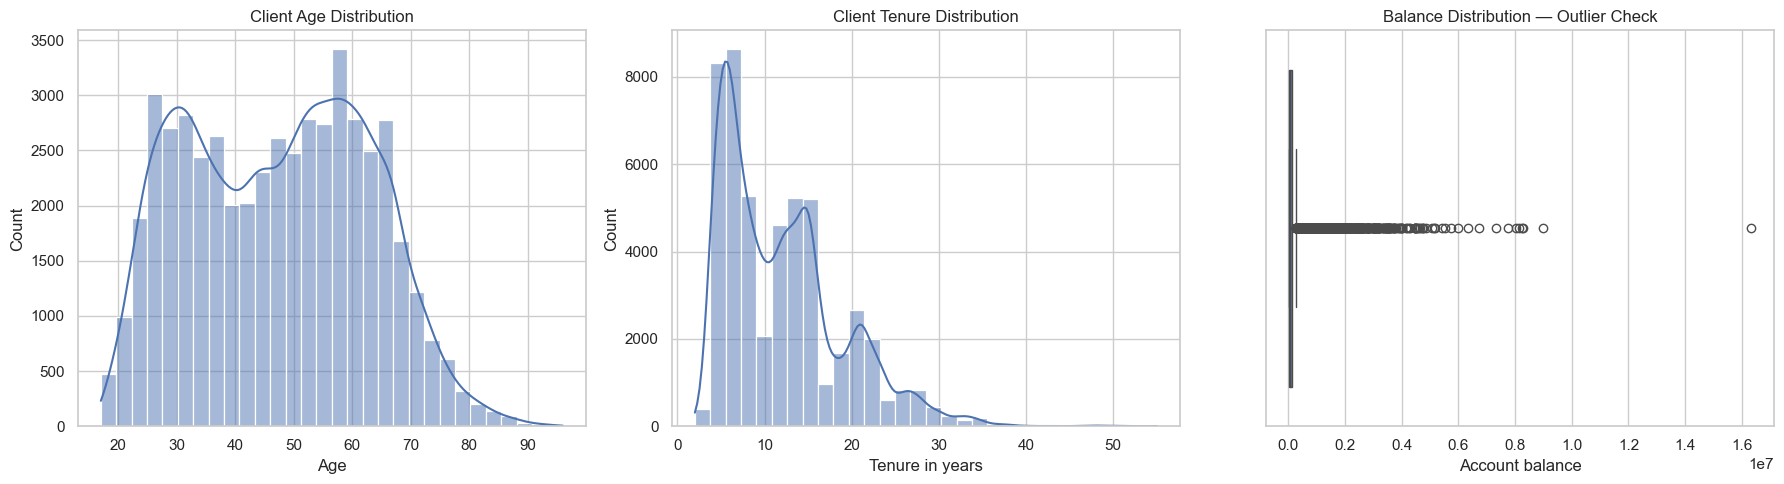

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=client, x="clnt_age", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Client Age Distribution")
axes[0].set_xlabel("Age")

sns.histplot(data=client, x="clnt_tenure_yr", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Client Tenure Distribution")
axes[1].set_xlabel("Tenure in years")

sns.boxplot(data=client, x="bal", ax=axes[2])
axes[2].set_title("Balance Distribution — Outlier Check")
axes[2].set_xlabel("Account balance")

plt.tight_layout()
plt.show()

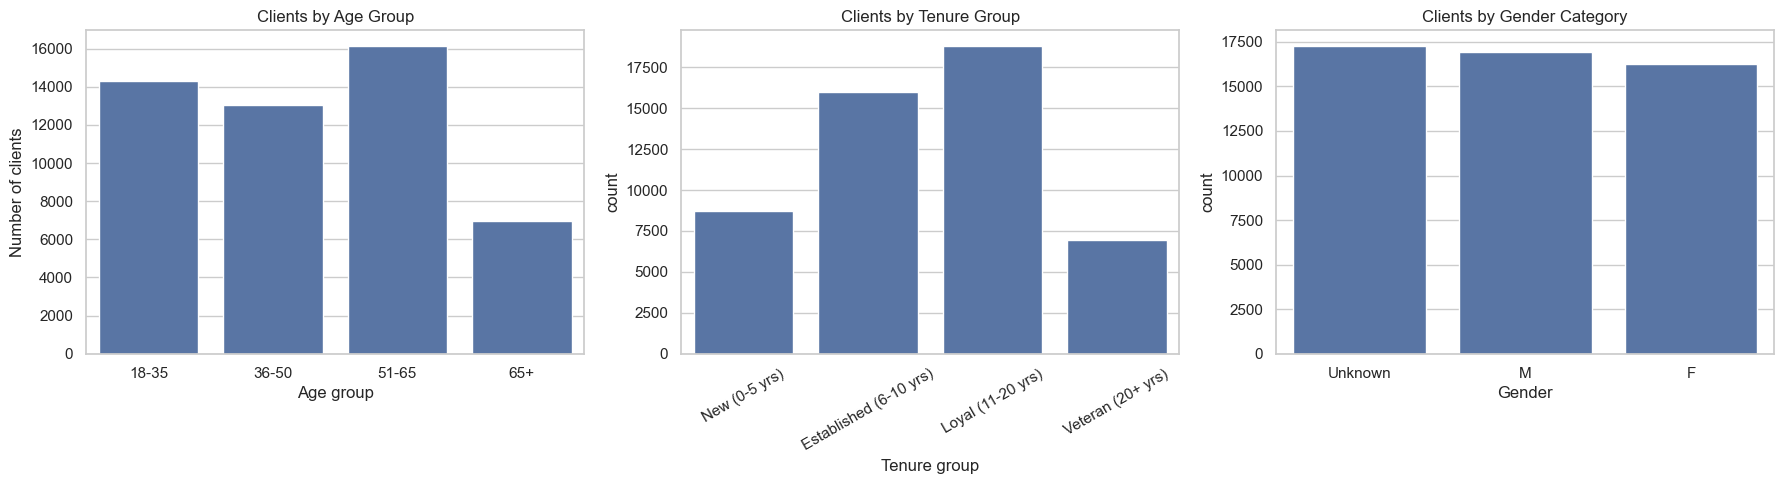

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=client, x="age_group", order=["18-35", "36-50", "51-65", "65+"], ax=axes[0])
axes[0].set_title("Clients by Age Group")
axes[0].set_xlabel("Age group")
axes[0].set_ylabel("Number of clients")

sns.countplot(data=client, x="tenure_group", ax=axes[1])
axes[1].set_title("Clients by Tenure Group")
axes[1].set_xlabel("Tenure group")
axes[1].tick_params(axis="x", rotation=30)

sns.countplot(data=client, x="gendr", ax=axes[2])
axes[2].set_title("Clients by Gender Category")
axes[2].set_xlabel("Gender")

plt.tight_layout()
plt.show()


#### Interpretation — Primary client profile

- The primary clients appear to be concentrated in the **51-65 Age group** segment.
- The tenure distribution suggests that many users are **Loyal** clients.
- The balance distribution is highly skewed, so the **median balance** is more reliable than the mean for describing a typical client.
- Gender includes a large **Unknown** category, so gender-based conclusions should be interpreted carefully.


### 2.4 Are primary clients younger or older, new or long-standing?

This section answers the required demographic questions directly using age and tenure groups.


In [11]:
age_distribution = (
    client["age_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

tenure_distribution = (
    client["tenure_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("percentage")
    .to_frame()
)

print("Age group distribution (%):")
display(age_distribution)

print("Tenure group distribution (%):")
display(tenure_distribution)

Age group distribution (%):


,percentage
age_group,
51-65,31.9800
18-35,28.3800
36-50,25.8000
65+,13.8300


Tenure group distribution (%):


,percentage
tenure_group,
Loyal (11-20 yrs),37.2700
Established (6-10 yrs),31.6400
New (0-5 yrs),17.2900
Veteran (20+ yrs),13.7900



#### Interpretation — Age and tenure

> Vanguard's online process is mainly used by **middle-aged** clients and by **long-standing** clients. This matters because the redesigned UI needs to support the behavior and expectations of this dominant user segment.



### 2.5 Client behavior analysis: digital engagement and support dependency

The project brief asks us to go beyond demographics. Since this is a Customer Experience experiment, it is useful to analyze whether clients are self-sufficient online or still rely heavily on support calls.


In [12]:
behavior_summary = client.groupby("digital_engagement").agg(
    clients=("client_id", "count"),
    avg_logons=("logons_6_mnth", "mean"),
    avg_calls=("calls_6_mnth", "mean"),
    avg_visits=("n_visits", "mean"),
    avg_events=("n_events", "mean"),
    median_balance=("bal", "median")
).round(2)

behavior_summary

,clients,avg_logons,avg_calls,avg_visits,avg_events,median_balance
digital_engagement,,,,,,
Low,7311,3.0000,0.0000,1.2300,5.7800,"46,780.4200"
Medium,21103,4.9100,1.8500,1.2800,6.0300,"58,282.2600"
High,22073,8.3400,5.3000,1.5100,6.6900,"87,483.6000"


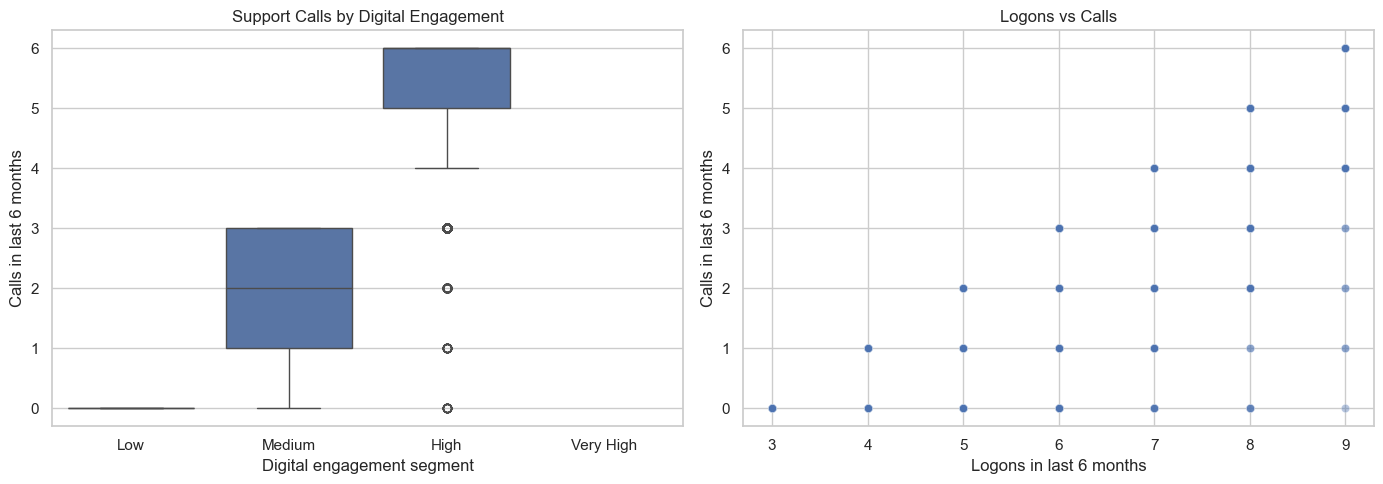

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=client, x="digital_engagement", y="calls_6_mnth", ax=axes[0])
axes[0].set_title("Support Calls by Digital Engagement")
axes[0].set_xlabel("Digital engagement segment")
axes[0].set_ylabel("Calls in last 6 months")

sns.scatterplot(data=client, x="logons_6_mnth", y="calls_6_mnth", alpha=0.4, ax=axes[1])
axes[1].set_title("Logons vs Calls")
axes[1].set_xlabel("Logons in last 6 months")
axes[1].set_ylabel("Calls in last 6 months")

plt.tight_layout()
plt.show()


#### Interpretation — Digital behavior

Potential business interpretation to refine after running the numbers:

- Clients with high digital engagement may be comfortable using Vanguard's platform, but if they also show many support calls, this can indicate unresolved friction.
- Clients with low logons and high calls may need clearer guidance, better onboarding, or more accessible digital flows.
- This behavior context is important because the redesigned UI aims to reduce friction and help users complete the process independently.


### 2.5.1 High-Value Clients Analysis 

Do high-balance clients behave differently? 

In [14]:
client.groupby("balance_segment").agg(
    avg_logons=("logons_6_mnth","mean"),
    avg_calls=("calls_6_mnth","mean"),
    clients=("client_id","count")
)

,avg_logons,avg_calls,clients
balance_segment,,,
Low,5.3907,2.3598,12622
Medium,5.8877,2.8583,12622
High,6.2966,3.2611,12621
Very High,6.9523,3.8940,12622


<Axes: xlabel='balance_segment', ylabel='logons_6_mnth'>

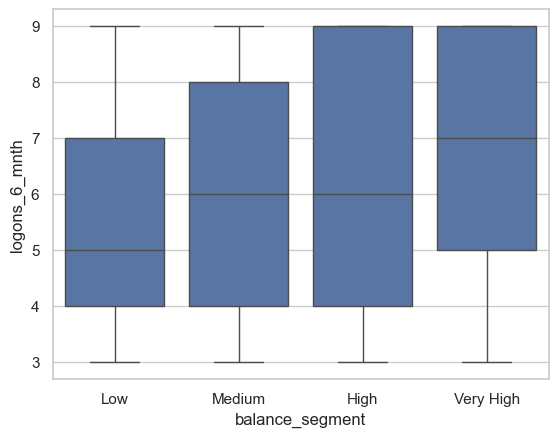

In [15]:
sns.boxplot(
    data=client,
    x="balance_segment",
    y="logons_6_mnth"
)

Higher-balance clients tend to engage more frequently with Vanguard's digital platform, suggesting that digitally active clients may also represent higher-value customer segments.


### 2.6 Experiment readiness check: are Test and Control groups balanced?

Before comparing KPIs, we check whether Test and Control users look similar across key demographic and account variables. This does not prove perfect randomization, but it helps us identify potential bias.


In [16]:

balance_check = client.groupby("Variation").agg(
    clients=("client_id", "count"),
    avg_age=("clnt_age", "mean"),
    median_age=("clnt_age", "median"),
    avg_tenure=("clnt_tenure_yr", "mean"),
    median_tenure=("clnt_tenure_yr", "median"),
    avg_balance=("bal", "mean"),
    median_balance=("bal", "median"),
    avg_logons=("logons_6_mnth", "mean"),
    avg_calls=("calls_6_mnth", "mean")
).round(2)

balance_check


,clients,avg_age,median_age,avg_tenure,median_tenure,avg_balance,median_balance,avg_logons,avg_calls
Variation,,,,,,,,,
Control,23532,47.5000,48.5000,12.0900,11.0000,"150,151.9000","66,031.4500",6.1700,3.1300
Test,26968,47.1600,47.5000,11.9800,11.0000,"148,962.6100","65,468.3600",6.1000,3.0600


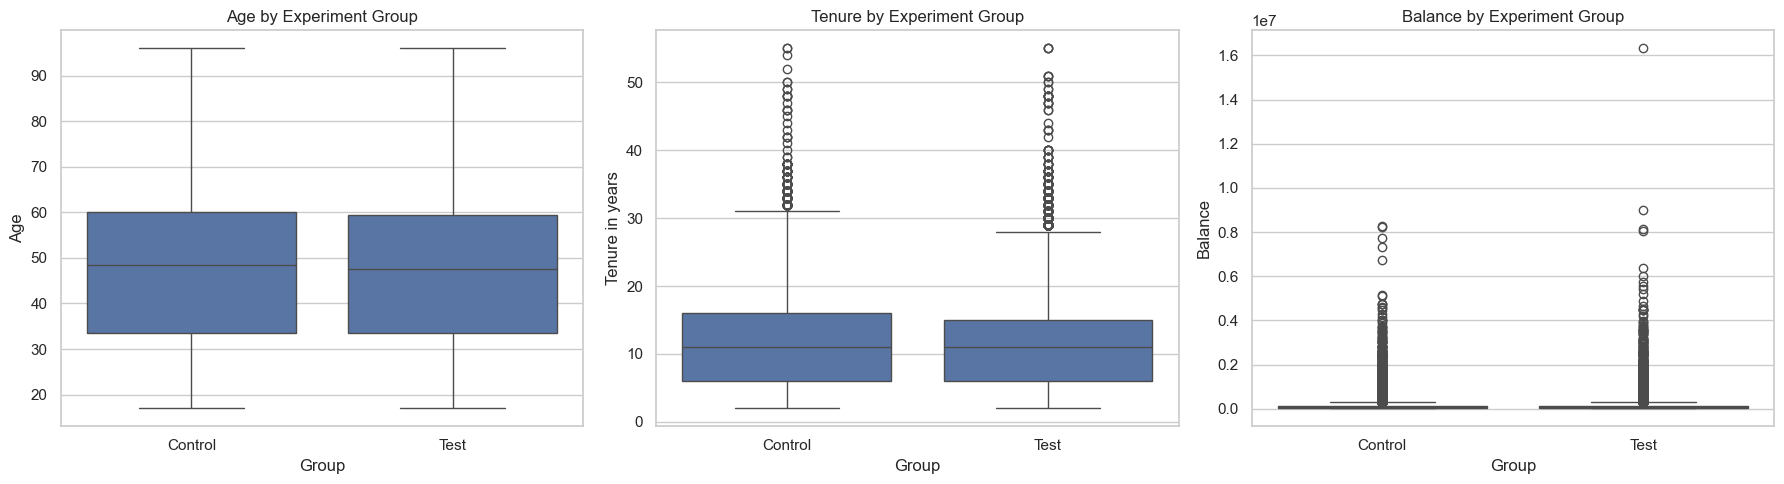

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=client, x="Variation", y="clnt_age", order=["Control", "Test"], ax=axes[0])
axes[0].set_title("Age by Experiment Group")
axes[0].set_xlabel("Group")
axes[0].set_ylabel("Age")

sns.boxplot(data=client, x="Variation", y="clnt_tenure_yr", order=["Control", "Test"], ax=axes[1])
axes[1].set_title("Tenure by Experiment Group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Tenure in years")

sns.boxplot(data=client, x="Variation", y="bal", order=["Control", "Test"], ax=axes[2])
axes[2].set_title("Balance by Experiment Group")
axes[2].set_xlabel("Group")
axes[2].set_ylabel("Balance")

plt.tight_layout()
plt.show()


#### Interpretation — Experiment readiness

Test and Control groups appear broadly comparable across age, tenure and account balance. This supports a fair descriptive comparison of the redesign. However, formal statistical testing and additional experiment design checks are addressed later in the project.


---

# Phase 2 — Performance Metrics / KPIs

Now that we understand the client base and have checked the experiment groups, we can evaluate whether the redesigned UI improved the online journey.

## 3. Completion Rate

**Definition:** the proportion of journeys that reach the final `confirm` step.
This is the headline KPI - the experiment exists to move this number.

In [18]:
# Visit-level completion
completion = visit.groupby("Variation")["reached_confirm"].agg(
    visits="size", completed="sum"
)
completion["completion_rate"] = completion["completed"] / completion["visits"]
completion

,visits,completed,completion_rate
Variation,,,
Control,32128,15999,0.4980
Test,37077,21681,0.5848


In [19]:
# Client-level cross-check: a client "completes" if ANY of their visits reached confirm
client_completion = (
    visit.groupby(["Variation", "client_id"])["reached_confirm"].max()
    .groupby("Variation").agg(clients="size", completed="sum")
)
client_completion["completion_rate"] = client_completion["completed"] / client_completion["clients"]
client_completion

,clients,completed,completion_rate
Variation,,,
Control,23439,15343,0.6546
Test,26873,18587,0.6917


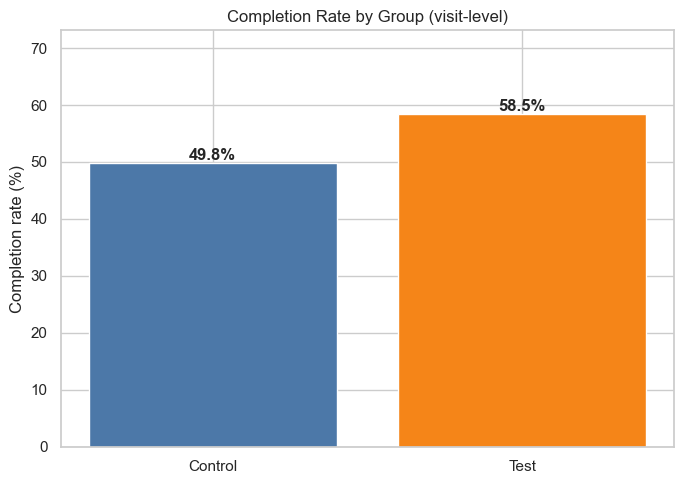

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
rates = (completion["completion_rate"] * 100).reindex(["Control", "Test"])
bars = ax.bar(rates.index, rates.values, color=[GROUP_COLORS[g] for g in rates.index])
ax.set_title("Completion Rate by Group (visit-level)")
ax.set_ylabel("Completion rate (%)")
ax.set_ylim(0, max(rates.values) * 1.25)
for b, v in zip(bars, rates.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Time Spent on Each Step

**Definition:** how long users dwell on a step before their next action.

**Method:** within each visit (sorted by time), the duration of an event is the
gap until the *next* event. That duration is attributed to the step the user was
on. The final event of each visit has no "next" event, so it is dropped
(this also naturally excludes `confirm`, which is terminal).

We report the **median** (robust to users who walk away mid-session and create
huge gaps) alongside the mean.

In [21]:
df_t = df.sort_values(["visit_id", "date_time"]).copy()
df_t["next_time"] = df_t.groupby("visit_id")["date_time"].shift(-1)
df_t["duration_sec"] = (df_t["next_time"] - df_t["date_time"]).dt.total_seconds()

# Keep only events that have a following event (drop the terminal event of each visit)
step_dur = df_t[df_t["duration_sec"].notna() & (df_t["duration_sec"] >= 0)].copy()

time_per_step = (
    step_dur.groupby(["Variation", "process_step"])["duration_sec"]
    .agg(mean_sec="mean", median_sec="median", n="size")
    .reindex(pd.MultiIndex.from_product([["Control", "Test"], STEP_NAMES[:-1]],
                                        names=["Variation", "process_step"]))
)
time_per_step

mean_sec  median_sec      n
Variation process_step                             
Control   start          66.8048     20.0000  35740
          step_1         50.5356     20.0000  26052
          step_2         92.0432     64.0000  24316
          step_3        137.2245     72.0000  20281
Test      start          61.4546     14.0000  46327
          step_1         60.7570     27.0000  35529
          step_2         88.8761     61.0000  29576
          step_3        129.6075     58.0000  23984

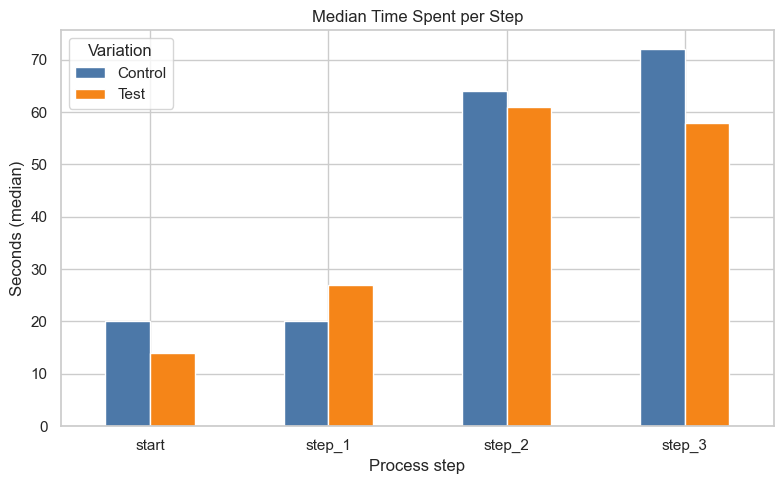

Variation,Control,Test
process_step,,
start,20.0000,14.0000
step_1,20.0000,27.0000
step_2,64.0000,61.0000
step_3,72.0000,58.0000


In [22]:
# Median time per step, side by side
pivot_med = time_per_step["median_sec"].unstack("Variation").reindex(STEP_NAMES[:-1])

ax = pivot_med[["Control", "Test"]].plot(
    kind="bar", figsize=(8, 5), color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]]
)
ax.set_title("Median Time Spent per Step")
ax.set_ylabel("Seconds (median)")
ax.set_xlabel("Process step")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
pivot_med

## 5. Error Rate (backward movements)

**Definition:** moving from a later step to an earlier step within the same
visit signals confusion or a mis-step. We flag any event whose step index is
lower than the previous event's index in that visit.

We report two views per group:
- **% of visits with at least one backward move** (did the journey ever stumble?)
- **backward moves per visit** (how often it stumbled)

In [23]:
df_t["prev_step_index"] = df_t.groupby("visit_id")["step_index"].shift(1)
df_t["is_backward"] = df_t["step_index"] < df_t["prev_step_index"]

visit_err = df_t.groupby("visit_id").agg(
    Variation     =("Variation", "first"),
    backward_moves=("is_backward", "sum"),
    total_steps   =("process_step", "size"),
)
visit_err["has_error"] = visit_err["backward_moves"] > 0

error_summary = visit_err.groupby("Variation").agg(
    visits           =("has_error", "size"),
    visits_with_error=("has_error", "sum"),
    total_backward   =("backward_moves", "sum"),
    total_steps      =("total_steps", "sum"),
)
error_summary["pct_visits_with_error"] = error_summary["visits_with_error"] / error_summary["visits"]
error_summary["backward_per_visit"]    = error_summary["total_backward"] / error_summary["visits"]
error_summary["error_rate_per_step"]   = error_summary["total_backward"] / error_summary["total_steps"]
error_summary

,visits,visits_with_error,total_backward,total_steps,pct_visits_with_error,backward_per_visit,error_rate_per_step
Variation,,,,,,,
Control,32120,6576,9685,140422,0.2047,0.3015,0.0690
Test,37085,10043,16355,176813,0.2708,0.4410,0.0925


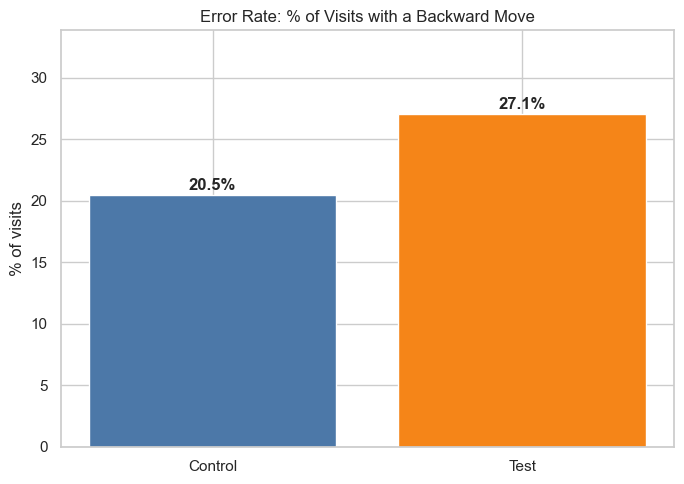

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
vals = (error_summary["pct_visits_with_error"] * 100).reindex(["Control", "Test"])
bars = ax.bar(vals.index, vals.values, color=[GROUP_COLORS[g] for g in vals.index])
ax.set_title("Error Rate: % of Visits with a Backward Move")
ax.set_ylabel("% of visits")
ax.set_ylim(0, max(vals.values) * 1.25)
for b, v in zip(bars, vals.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Additional KPIs

To round out the picture beyond the three required KPIs:

- **Funnel drop-off** - share of visits that reach at least each step
- **Bounce rate** - visits that never progress past `start`
- **Step repeats** - visits that revisit the same step (hesitation / re-loading)
- **Time-to-complete** - for completed journeys, total minutes from start to confirm

In [25]:
# --- Funnel: share of visits reaching at least each step ---
funnel = {}
for name, idx in STEP_ORDER.items():
    funnel[name] = visit.groupby("Variation")["max_step"].apply(lambda s: (s >= idx).mean())
funnel = pd.DataFrame(funnel).T.reindex(STEP_NAMES)[["Control", "Test"]]
print("Share of visits reaching at least each step:")
funnel

Share of visits reaching at least each step:


Variation,Control,Test
start,1.0000,1.0000
step_1,0.7647,0.8630
step_2,0.6562,0.7577
step_3,0.5928,0.6885
confirm,0.4980,0.5848


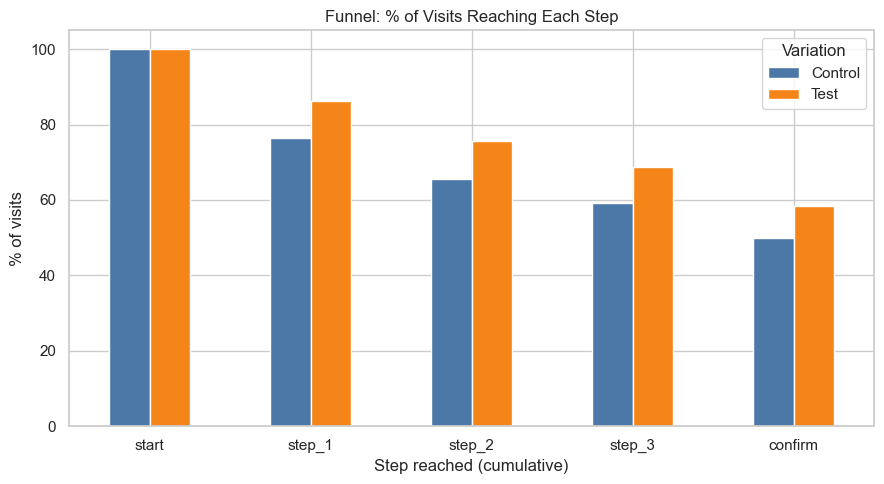

In [26]:
ax = (funnel * 100).plot(kind="bar", figsize=(9, 5),
                         color=[GROUP_COLORS["Control"], GROUP_COLORS["Test"]])
ax.set_title("Funnel: % of Visits Reaching Each Step")
ax.set_ylabel("% of visits")
ax.set_xlabel("Step reached (cumulative)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

In [27]:
# --- Bounce rate: visits that never get past 'start' ---
bounce = visit.assign(bounce=visit["max_step"] == 0).groupby("Variation")["bounce"].mean()

# --- Step repeats: visit revisits the same step at least once ---
step_counts = df.groupby(["visit_id", "process_step"]).size()
visit_has_repeat = (step_counts > 1).groupby(level=0).any()
repeat_rate = (
    visit_has_repeat.to_frame("has_repeat")
    .join(visit[["Variation"]])
    .groupby("Variation")["has_repeat"].mean()
)

# --- Time-to-complete (completed visits only), in minutes ---
completed = visit[visit["reached_confirm"]].copy()
completed["total_min"] = (completed["end_time"] - completed["start_time"]).dt.total_seconds() / 60
ttc = completed.groupby("Variation")["total_min"].agg(median_min="median", mean_min="mean")

extra = pd.DataFrame({
    "bounce_rate":        bounce,
    "step_repeat_rate":   repeat_rate,
    "ttc_median_min":     ttc["median_min"],
    "ttc_mean_min":       ttc["mean_min"],
}).reindex(["Control", "Test"])
extra

,bounce_rate,step_repeat_rate,ttc_median_min,ttc_mean_min
Variation,,,,
Control,0.2353,0.3748,4.4833,6.6305
Test,0.1370,0.4501,3.5833,6.0666


## 7. KPI Summary and Redesign Verdict

All KPIs consolidated into one Test-vs-Control comparison with the lift
(Test - Control). For completion, funnel and time-to-complete, higher/faster is
better; for error, bounce and step-repeat rates, lower is better.

In [28]:
def g(series, grp):
    return series.loc[grp]

summary = pd.DataFrame({
    "Control": {
        "Completion rate (visit)":       g(completion["completion_rate"], "Control"),
        "Completion rate (client)":      g(client_completion["completion_rate"], "Control"),
        "Error rate (% visits)":         g(error_summary["pct_visits_with_error"], "Control"),
        "Backward moves / visit":        g(error_summary["backward_per_visit"], "Control"),
        "Bounce rate":                   g(bounce, "Control"),
        "Step-repeat rate":              g(repeat_rate, "Control"),
        "Time-to-complete (median min)": g(ttc["median_min"], "Control"),
    },
    "Test": {
        "Completion rate (visit)":       g(completion["completion_rate"], "Test"),
        "Completion rate (client)":      g(client_completion["completion_rate"], "Test"),
        "Error rate (% visits)":         g(error_summary["pct_visits_with_error"], "Test"),
        "Backward moves / visit":        g(error_summary["backward_per_visit"], "Test"),
        "Bounce rate":                   g(bounce, "Test"),
        "Step-repeat rate":              g(repeat_rate, "Test"),
        "Time-to-complete (median min)": g(ttc["median_min"], "Test"),
    },
})
summary["Lift (Test - Control)"] = summary["Test"] - summary["Control"]
summary

,Control,Test,Lift (Test - Control)
Completion rate (visit),0.4980,0.5848,0.0868
Completion rate (client),0.6546,0.6917,0.0371
Error rate (% visits),0.2047,0.2708,0.0661
Backward moves / visit,0.3015,0.4410,0.1395
Bounce rate,0.2353,0.1370,-0.0983
Step-repeat rate,0.3748,0.4501,0.0753
Time-to-complete (median min),4.4833,3.5833,-0.9000


In [29]:
# Data-driven narrative so the conclusion always matches the numbers
ct = completion.loc["Test", "completion_rate"]
cc = completion.loc["Control", "completion_rate"]
rel = (ct - cc) / cc * 100
et = error_summary.loc["Test", "pct_visits_with_error"]
ec = error_summary.loc["Control", "pct_visits_with_error"]

print("REDESIGN SCORECARD (Test vs Control)")
print("-" * 48)
print(f"Completion rate : {ct:.1%} vs {cc:.1%}  "
      f"({(ct-cc)*100:+.1f} pp, {rel:+.1f}% relative)")
print(f"Error rate      : {et:.1%} vs {ec:.1%}  ({(et-ec)*100:+.1f} pp)")
print(f"Bounce rate     : {bounce['Test']:.1%} vs {bounce['Control']:.1%}")
print(f"Time-to-complete: {ttc.loc['Test','median_min']:.1f} vs "
      f"{ttc.loc['Control','median_min']:.1f} min (median)")
print("-" * 48)
print("Note: statistical significance of these differences is tested in Phase 3.")

REDESIGN SCORECARD (Test vs Control)
------------------------------------------------
Completion rate : 58.5% vs 49.8%  (+8.7 pp, +17.4% relative)
Error rate      : 27.1% vs 20.5%  (+6.6 pp)
Bounce rate     : 13.7% vs 23.5%
Time-to-complete: 3.6 vs 4.5 min (median)
------------------------------------------------
Note: statistical significance of these differences is tested in Phase 3.


### Interpretation

Read the scorecard above together with the summary table:

- **Completion rate** is the primary success measure. A positive lift means the
  redesign moved more journeys to `confirm`.
- **Error rate / backward moves** indicate confusion. The redesign should reduce
  these if the new UI is clearer.
- **Time per step / time-to-complete** show efficiency - but interpret with care:
  more time on the new UI is not automatically bad if completion also rises.
- **Bounce and step-repeat rates** capture early abandonment and hesitation.

> **Important:** these are descriptive differences. Whether the completion-rate
> lift is **statistically significant** (and whether it clears Vanguard's
> cost-effectiveness threshold) is answered in **Phase 3 - Hypothesis Testing**.

## Business Recommendation

The redesigned experience should be considered for broader deployment if the hypothesis testing phase confirms that the observed completion-rate improvement is statistically significant and exceeds Vanguard's predefined 5% business threshold.

In addition to increasing completion rates, the redesign should be evaluated based on its ability to reduce friction, decrease error rates, and improve overall journey efficiency.